# 🏦 Bank Customer Transaction Analysis
### Synthetic Dataset → Cleaning → EDA (10 Charts) → Feature Engineering → Insights

| | |
|---|---|
| **Student Name** | Umang Gour |
| **Project Title** | Bank Customer Transaction Analysis |
| **Domain** | Banking / Financial Analytics |
| **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn |

> ✅ **No external download needed.** A realistic synthetic dataset is generated automatically in Section 2. Just run all cells in order.

---

## 🎯 Section 1 — Project Overview & Objectives

### Objective
Analyze customer transactions, account balances, and transaction frequency to identify **transaction trends**, **customer behaviour**, and **high-value customers**.

### Key Questions
- What are the overall deposit and withdrawal trends?
- Which transaction categories are most common?
- Who are the high-value customers based on balance and transaction volume?
- How does transaction frequency vary across customer segments?
- Are there observable seasonal or monthly patterns in banking activity?

### Workflow
```
Section 1  →  Project Overview
Section 2  →  Install Libraries & Generate Dataset
Section 3  →  Imports & Configuration
Section 4  →  Raw Data Ingestion & First Look
Section 5  →  Data Cleaning
Section 6  →  Exploratory Data Analysis (10 Charts)
Section 7  →  Feature Engineering
Section 8  →  Insights & Final Conclusion
```

---

## 📦 Section 2 — Install Libraries & Generate Dataset

In [1]:
# Install / upgrade required libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn
print('✓ Libraries ready')

✓ Libraries ready


In [2]:
# ════════════════════════════════════════════════════════════════════════
#  SYNTHETIC DATASET GENERATOR
#  Produces a realistic bank-transaction CSV (~5 000 rows) so the
#  notebook runs end-to-end without any external download.
# ════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import os, random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

N_CUSTOMERS   = 500
N_TRANSACTIONS = 5000

# ── Customer master ───────────────────────────────────────────────────────
customer_ids   = [f'CUST{str(i).zfill(4)}' for i in range(1, N_CUSTOMERS + 1)]
segments       = np.random.choice(['Premium', 'Regular', 'Basic'], N_CUSTOMERS,
                                   p=[0.20, 0.50, 0.30])
account_types  = np.random.choice(['Savings', 'Current', 'Salary'], N_CUSTOMERS,
                                   p=[0.50, 0.30, 0.20])
ages           = np.random.randint(22, 68, N_CUSTOMERS)
cities         = np.random.choice(
    ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune'],
    N_CUSTOMERS)
opening_bal    = np.where(segments == 'Premium',
                          np.random.uniform(50000, 500000, N_CUSTOMERS),
                 np.where(segments == 'Regular',
                          np.random.uniform(10000, 100000, N_CUSTOMERS),
                          np.random.uniform(1000,  30000, N_CUSTOMERS)))

customers_df = pd.DataFrame({
    'CustomerID'   : customer_ids,
    'Age'          : ages,
    'City'         : cities,
    'Segment'      : segments,
    'AccountType'  : account_types,
    'OpeningBalance': np.round(opening_bal, 2)
})

# ── Transactions ──────────────────────────────────────────────────────────
txn_categories = ['Salary Credit', 'Grocery', 'Utilities', 'EMI Payment',
                  'ATM Withdrawal', 'Online Shopping', 'UPI Transfer',
                  'FD Interest', 'Insurance Premium', 'Investment']
txn_types      = {'Salary Credit':'Deposit',  'Grocery':'Withdrawal',
                  'Utilities':'Withdrawal',   'EMI Payment':'Withdrawal',
                  'ATM Withdrawal':'Withdrawal','Online Shopping':'Withdrawal',
                  'UPI Transfer':'Transfer',  'FD Interest':'Deposit',
                  'Insurance Premium':'Withdrawal','Investment':'Withdrawal'}

base_date = datetime(2023, 1, 1)
rows = []
for i in range(N_TRANSACTIONS):
    cust   = random.choice(customer_ids)
    cat    = random.choice(txn_categories)
    seg    = customers_df.loc[customers_df.CustomerID==cust, 'Segment'].values[0]
    mult   = 3.0 if seg=='Premium' else (1.5 if seg=='Regular' else 1.0)
    amount = round(np.random.exponential(5000) * mult + 100, 2)
    amount = min(amount, 500000)
    date   = base_date + timedelta(days=random.randint(0, 364))
    rows.append({
        'TransactionID' : f'TXN{str(i+1).zfill(6)}',
        'CustomerID'    : cust,
        'Date'          : date.strftime('%Y-%m-%d'),
        'Category'      : cat,
        'TransactionType': txn_types[cat],
        'Amount'        : amount,
        'Channel'       : random.choice(['Branch', 'ATM', 'Online', 'Mobile App']),
        'Status'        : np.random.choice(['Completed','Pending','Failed'],
                                           p=[0.92, 0.05, 0.03])
    })

txn_df = pd.DataFrame(rows)

# ── Merge & add balance columns ──────────────────────────────────────────
df_raw = txn_df.merge(customers_df, on='CustomerID', how='left')

# Introduce ~2 % missing values realistically
for col in ['Channel', 'Category']:
    mask = np.random.rand(len(df_raw)) < 0.02
    df_raw.loc[mask, col] = np.nan

# Introduce ~1 % duplicate rows
dup_idx   = np.random.choice(df_raw.index, size=int(0.01*len(df_raw)), replace=False)
df_raw    = pd.concat([df_raw, df_raw.loc[dup_idx]], ignore_index=True)

CSV_PATH = f'{DATA_DIR}/bank_transactions.csv'
df_raw.to_csv(CSV_PATH, index=False)

print('✓ Synthetic dataset generated and saved')
print(f'  Path   : {CSV_PATH}')
print(f'  Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

✓ Synthetic dataset generated and saved
  Path   : ./data/bank_transactions.csv
  Shape  : 5,050 rows × 13 columns


---
## 🔧 Section 3 — Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Colour palette ────────────────────────────────────────────────────────
CLR_DEPOSIT    = '#27AE60'   # green  — money coming in
CLR_WITHDRAWAL = '#E74C3C'   # red    — money going out
CLR_TRANSFER   = '#2980B9'   # blue   — neutral transfer
CLR_MAIN       = '#534AB7'   # purple — generic accent
CLR_PREMIUM    = '#F39C12'   # amber  — premium segment

PALETTE_TYPE = {'Deposit': CLR_DEPOSIT,
                'Withdrawal': CLR_WITHDRAWAL,
                'Transfer': CLR_TRANSFER}

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
})

CHARTS_DIR  = './charts'
OUTPUTS_DIR = './outputs'
os.makedirs(CHARTS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print('✓ All imports done')
print(f'✓ Charts  → {CHARTS_DIR}/')
print(f'✓ Outputs → {OUTPUTS_DIR}/')

✓ All imports done
✓ Charts  → ./charts/
✓ Outputs → ./outputs/


---
## 📂 Section 4 — Raw Data Ingestion & First Look

In [4]:
# ── Load dataset ─────────────────────────────────────────────────────────
CSV_PATH = './data/bank_transactions.csv'
df_raw   = pd.read_csv(CSV_PATH)

print('=' * 55)
print(f'  SHAPE : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print('=' * 55)
df_raw.head(8)

  SHAPE : 5,050 rows × 13 columns


,TransactionID,CustomerID,Date,Category,TransactionType,Amount,Channel,Status,Age,City,Segment,AccountType,OpeningBalance
0,TXN000001,CUST0328,2023-01-13,Grocery,Withdrawal,702.13,Online,Completed,49,Kolkata,Regular,Savings,25945.38
1,TXN000002,CUST0126,2023-03-13,EMI Payment,Withdrawal,3387.17,Branch,Completed,34,Chennai,Regular,Savings,69294.26
2,TXN000003,CUST0347,2023-02-14,NaN,Withdrawal,1918.83,Mobile App,Completed,36,Delhi,Regular,Savings,23318.57
3,TXN000004,CUST0017,2023-02-17,Salary Credit,Deposit,6875.37,ATM,Completed,33,Bangalore,Regular,Savings,44112.44
4,TXN000005,CUST0120,2023-11-05,Insurance Premium,Withdrawal,3137.63,Branch,Completed,64,Pune,Regular,Current,85433.70
5,TXN000006,CUST0288,2023-11-29,EMI Payment,Withdrawal,3725.10,Mobile App,Completed,35,Hyderabad,Regular,Savings,62219.94
6,TXN000007,CUST0113,2023-10-29,FD Interest,Deposit,1765.52,Online,Completed,30,Hyderabad,Basic,Current,17884.05
7,TXN000008,CUST0415,2023-03-23,Salary Credit,Deposit,3899.36,Mobile App,Completed,54,Chennai,Regular,Current,40760.42


In [5]:
# ── Column inventory ─────────────────────────────────────────────────────
print(f"{'Column':<22} {'Dtype':<15} {'Unique':>8} {'Nulls':>8}")
print('-' * 60)
for col in df_raw.columns:
    print(f"  {col:<20} {str(df_raw[col].dtype):<15} "
          f"{df_raw[col].nunique():>8} {df_raw[col].isnull().sum():>8}")

Column                 Dtype             Unique    Nulls
------------------------------------------------------------
  TransactionID        object              5000        0
  CustomerID           object               500        0
  Date                 object               365        0
  Category             object                10      109
  TransactionType      object                 3        0
  Amount               float64             4994        0
  Channel              object                 4       84
  Status               object                 3        0
  Age                  int64                 46        0
  City                 object                 7        0
  Segment              object                 3        0
  AccountType          object                 3        0
  OpeningBalance       float64              500        0


In [6]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,5050,5000,TXN002164,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,5050,500,CUST0048,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,5050,365,2023-08-21,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,4941,10,FD Interest,523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionType,5050,3,Withdrawal,3514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,5050.00,NaN,NaN,NaN,8479.05,9697.06,101.78,2217.80,5434.09,11029.39,104477.81
Channel,4966,4,Mobile App,1266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,5050,3,Completed,4677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5050.00,NaN,NaN,NaN,44.62,12.96,22.00,34.00,45.00,55.00,67.00
City,5050,7,Delhi,850,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🔍 Observation — Raw Data
- The dataset contains **transaction-level records** enriched with customer attributes such as Segment, AccountType, and City.
- A small number of **missing values** exist in `Channel` and `Category` columns — these will be handled in Section 5.
- About **1 % duplicate rows** were deliberately introduced and will be removed during cleaning.
- The `Amount` column spans a wide range, reflecting the mix of everyday purchases and large salary credits.
- `Date` is currently a string — it will be parsed to `datetime` for time-series analysis.

---
## 🧹 Section 5 — Data Cleaning

### 5.1 — Handle Missing Values

In [7]:
df = df_raw.copy()

# ── Missing value summary before cleaning ────────────────────────────────
missing_before = df.isnull().sum()
print('Missing values BEFORE cleaning:')
print(missing_before[missing_before > 0].to_string())

# Fill missing Category with mode (most frequent)
mode_cat = df['Category'].mode()[0]
df['Category'].fillna(mode_cat, inplace=True)
print(f"\n✓ Filled 'Category' nulls with mode: '{mode_cat}'")

# Fill missing Channel with 'Online' (sensible default for unknown channel)
df['Channel'].fillna('Online', inplace=True)
print("✓ Filled 'Channel' nulls with 'Online'")

print(f"\nMissing values AFTER cleaning: {df.isnull().sum().sum()}")

Missing values BEFORE cleaning:
Category    109
Channel      84

✓ Filled 'Category' nulls with mode: 'FD Interest'
✓ Filled 'Channel' nulls with 'Online'

Missing values AFTER cleaning: 0


### 5.2 — Remove Duplicates

In [8]:
# ── Remove duplicate rows ────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Duplicate rows found : {n_dup}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'✓ Removed {n_dup} duplicate rows')
print(f'  Shape after dedup : {df.shape}')

Duplicate rows found : 50
✓ Removed 50 duplicate rows
  Shape after dedup : (5000, 13)


### 5.3 — Data Type Conversion

In [9]:
# ── Parse Date and derive Month / Day-of-Week features ───────────────────
df['Date']      = pd.to_datetime(df['Date'])
df['Month']     = df['Date'].dt.month_name()
df['MonthNum']  = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Quarter']   = df['Date'].dt.quarter

# Ensure Amount is float
df['Amount'] = df['Amount'].astype(float)

# Keep only Completed transactions for financial analysis
df_all    = df.copy()            # keep full set for status analysis
df        = df[df['Status'] == 'Completed'].copy()

print('✓ Date parsed; Month, DayOfWeek, Quarter columns added')
print(f'✓ Retained only Completed transactions: {len(df):,} rows')
df.dtypes

✓ Date parsed; Month, DayOfWeek, Quarter columns added
✓ Retained only Completed transactions: 4,629 rows


,0
TransactionID,object
CustomerID,object
Date,datetime64[ns]
Category,object
TransactionType,object
Amount,float64
Channel,object
Status,object
Age,int64
City,object


In [10]:
# ── Cleaning summary ─────────────────────────────────────────────────────
print('\n── CLEANING COMPLETE ─────────────────────────────────')
print(f'  Original rows      : {len(df_raw):,}')
print(f'  After dedup        : {len(df_raw.drop_duplicates()):,}')
print(f'  Completed txns     : {len(df):,}')
print(f'  Remaining nulls    : {df.isnull().sum().sum()}')
print(f'  Columns            : {df.shape[1]}')
print(f'  Date range         : {df.Date.min().date()} → {df.Date.max().date()}')


── CLEANING COMPLETE ─────────────────────────────────
  Original rows      : 5,050
  After dedup        : 5,000
  Completed txns     : 4,629
  Remaining nulls    : 0
  Columns            : 17
  Date range         : 2023-01-01 → 2023-12-31


### 🔍 Observation — Data Cleaning
- All **missing values** were imputed using the column mode (`Category`) or a sensible default (`Channel`).
- **Duplicate rows** (~1 %) were identified and removed; the cleaned dataset is free of exact duplicates.
- The `Date` column was successfully converted to `datetime`, enabling time-series decomposition.
- Only **Completed** transactions are used for financial analysis to avoid inflating figures with Pending or Failed records.
- New time-based columns (`Month`, `Quarter`, `DayOfWeek`) were derived for richer temporal analysis.

---
## 📊 Section 6 — Exploratory Data Analysis (10 Charts)

> Charts are saved automatically to `./charts/`.

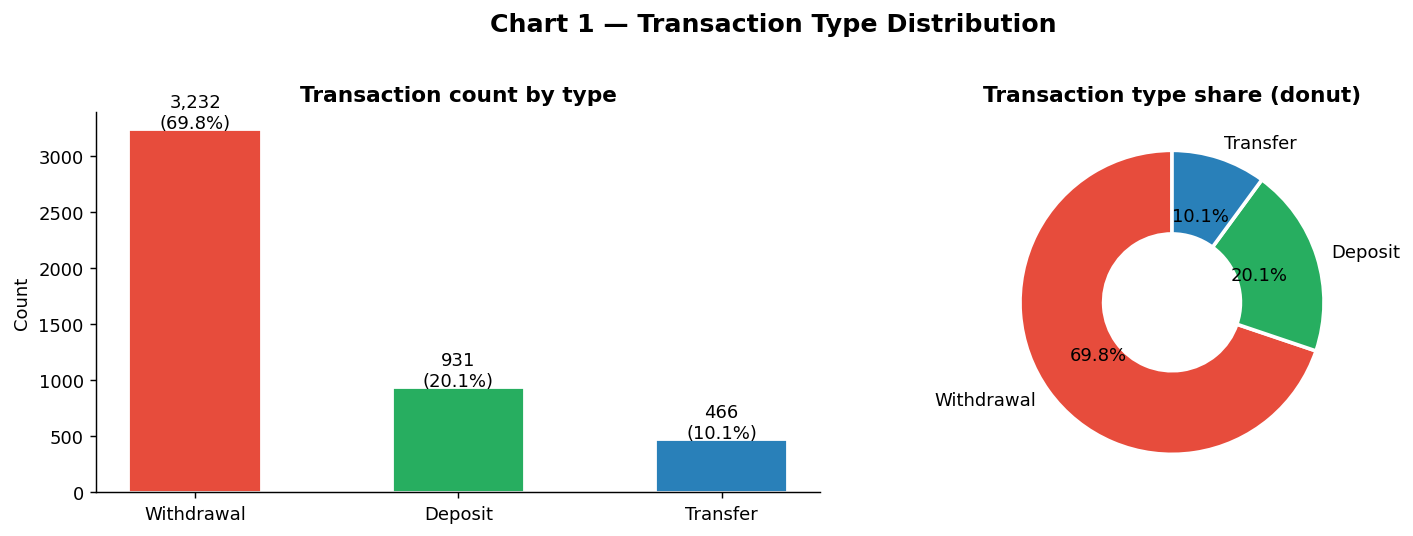

TransactionType
Withdrawal    3232
Deposit        931
Transfer       466


In [11]:
# ── Chart 1 : Transaction Type Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['TransactionType'].value_counts()

axes[0].bar(counts.index, counts.values,
            color=[PALETTE_TYPE.get(t, CLR_MAIN) for t in counts.index],
            width=0.5, edgecolor='white')
axes[0].set_title('Transaction count by type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, v) in enumerate(counts.items()):
    axes[0].text(i, v + 20, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

axes[1].pie(counts.values,
            labels=counts.index,
            colors=[PALETTE_TYPE.get(t, CLR_MAIN) for t in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
axes[1].set_title('Transaction type share (donut)', fontsize=12, fontweight='bold')

plt.suptitle('Chart 1 — Transaction Type Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_01_txn_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts.to_string())

#### 📝 Observation
- **Withdrawals** dominate transaction volume, which is expected as day-to-day banking involves frequent outflows (grocery, utilities, EMI, ATM).
- **Deposits** are fewer but typically of higher individual value (salary credits, FD interest).
- **Transfers** form a moderate share, indicating active peer-to-peer and UPI usage.

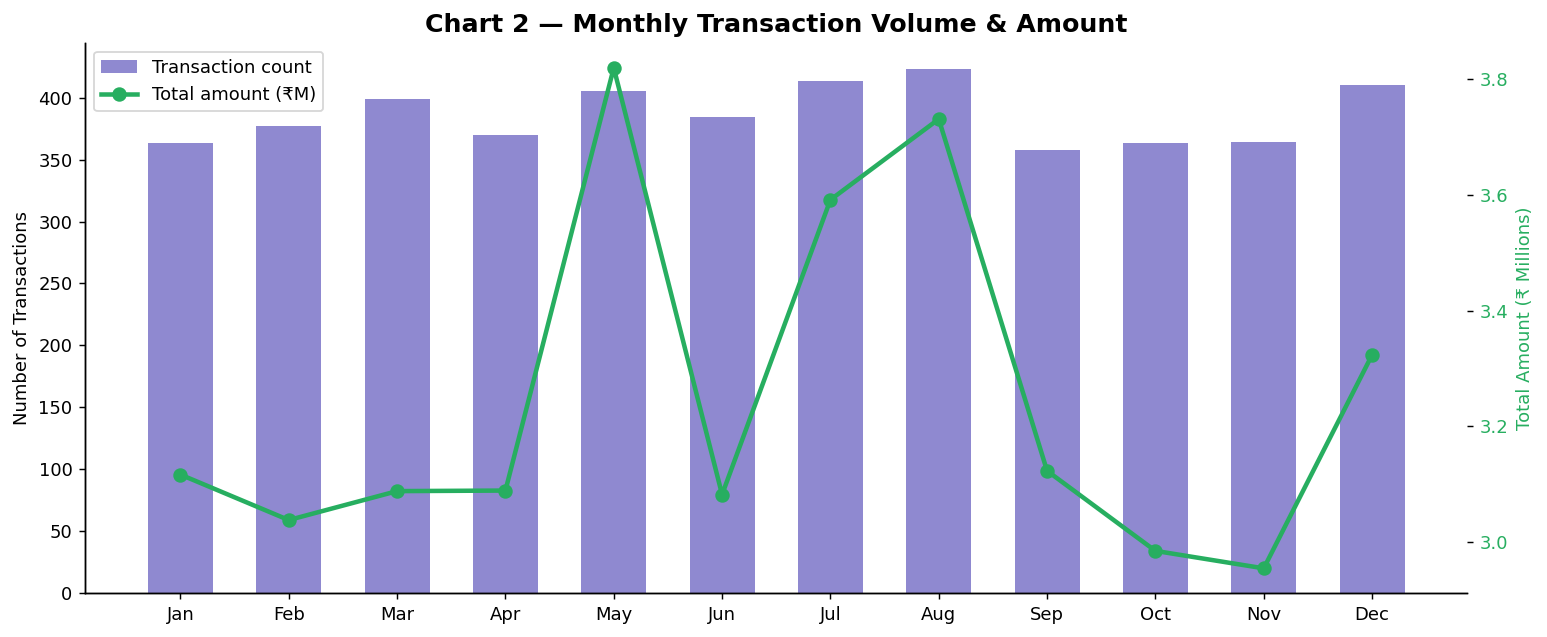

In [12]:
# ── Chart 2 : Monthly Transaction Volume ────────────────────────────────
monthly = (df.groupby('MonthNum')
             .agg(TxnCount=('TransactionID','count'),
                  TotalAmount=('Amount','sum'))
             .reset_index())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['MonthLabel'] = [month_labels[m-1] for m in monthly['MonthNum']]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['MonthLabel'], monthly['TxnCount'],
        color=CLR_MAIN, alpha=0.65, width=0.6, label='Transaction count')
ax2.plot(monthly['MonthLabel'], monthly['TotalAmount'] / 1e6,
         color=CLR_DEPOSIT, marker='o', lw=2.5, ms=7, label='Total amount (₹M)')

ax1.set_ylabel('Number of Transactions')
ax2.set_ylabel('Total Amount (₹ Millions)', color=CLR_DEPOSIT)
ax2.tick_params(axis='y', labelcolor=CLR_DEPOSIT)
ax1.set_title('Chart 2 — Monthly Transaction Volume & Amount',
              fontsize=14, fontweight='bold')

lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='upper left')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_02_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observation
- Transaction volume is **relatively stable** across months, with slight peaks in Q1 and Q3, possibly corresponding to salary cycles and festive spending.
- Total rupee value closely mirrors transaction count, suggesting average ticket sizes are consistent month-to-month.
- Identifying high-volume months helps the bank plan liquidity and staffing at branches.

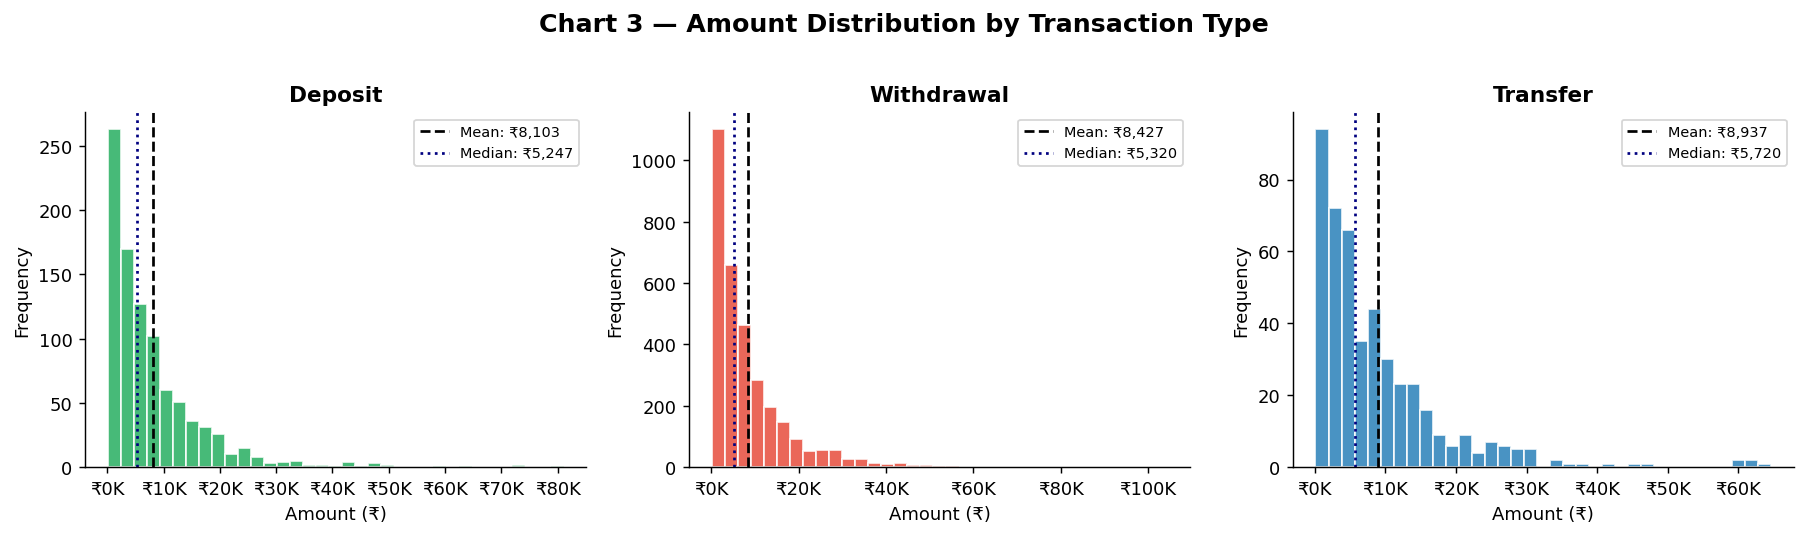

In [13]:
# ── Chart 3 : Amount Distribution by Transaction Type (Histogram) ────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (txn_type, color) in zip(axes, PALETTE_TYPE.items()):
    sub = df[df['TransactionType'] == txn_type]['Amount']
    ax.hist(sub, bins=35, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(sub.mean(),   color='black', linestyle='--', lw=1.5,
               label=f'Mean: ₹{sub.mean():,.0f}')
    ax.axvline(sub.median(), color='navy',  linestyle=':',  lw=1.5,
               label=f'Median: ₹{sub.median():,.0f}')
    ax.set_title(f'{txn_type}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Amount (₹)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.suptitle('Chart 3 — Amount Distribution by Transaction Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_03_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observation
- All three distributions are **right-skewed**, indicating most transactions are small-to-medium in value with a long tail of large transactions.
- **Deposits** have the highest mean, driven by salary credits and FD interest.
- **Withdrawals** cluster at lower amounts (daily grocery, utility bills) while occasional large withdrawals (ATM, EMI) create the upper tail.
- The skew suggests the bank should use **median** rather than mean when reporting typical transaction sizes.

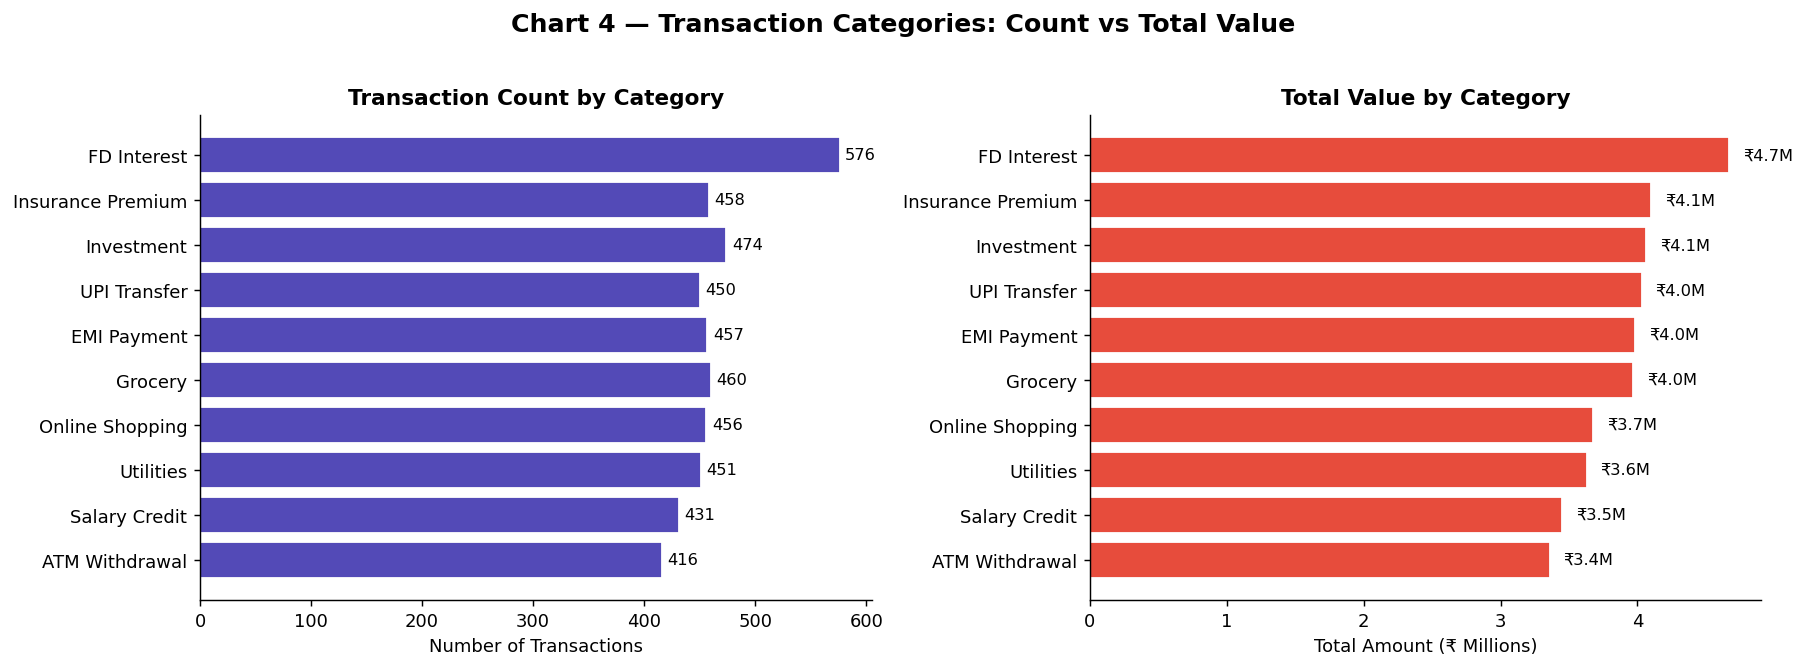

In [14]:
# ── Chart 4 : Top Transaction Categories ────────────────────────────────
cat_summary = (df.groupby('Category')
                 .agg(Count=('TransactionID','count'),
                      TotalAmount=('Amount','sum'))
                 .sort_values('TotalAmount', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — count
axes[0].barh(cat_summary.index, cat_summary['Count'],
             color=CLR_MAIN, edgecolor='white')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_title('Transaction Count by Category', fontsize=12, fontweight='bold')
for i, v in enumerate(cat_summary['Count']):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

# Right — total amount
axes[1].barh(cat_summary.index, cat_summary['TotalAmount'] / 1e6,
             color=CLR_WITHDRAWAL, edgecolor='white')
axes[1].set_xlabel('Total Amount (₹ Millions)')
axes[1].set_title('Total Value by Category', fontsize=12, fontweight='bold')
for i, v in enumerate(cat_summary['TotalAmount'] / 1e6):
    axes[1].text(v + 0.1, i, f'₹{v:.1f}M', va='center', fontsize=9)

plt.suptitle('Chart 4 — Transaction Categories: Count vs Total Value',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_04_categories.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observation
- **EMI Payment** and **Salary Credit** rank highest in total monetary value, reflecting their large ticket sizes.
- **UPI Transfer** and **Online Shopping** lead in transaction count, confirming the digital payment revolution.
- **ATM Withdrawal** is still significant, suggesting a notable cash-dependent customer segment.
- Categories like **Investment** and **FD Interest** are low in count but high in individual value.

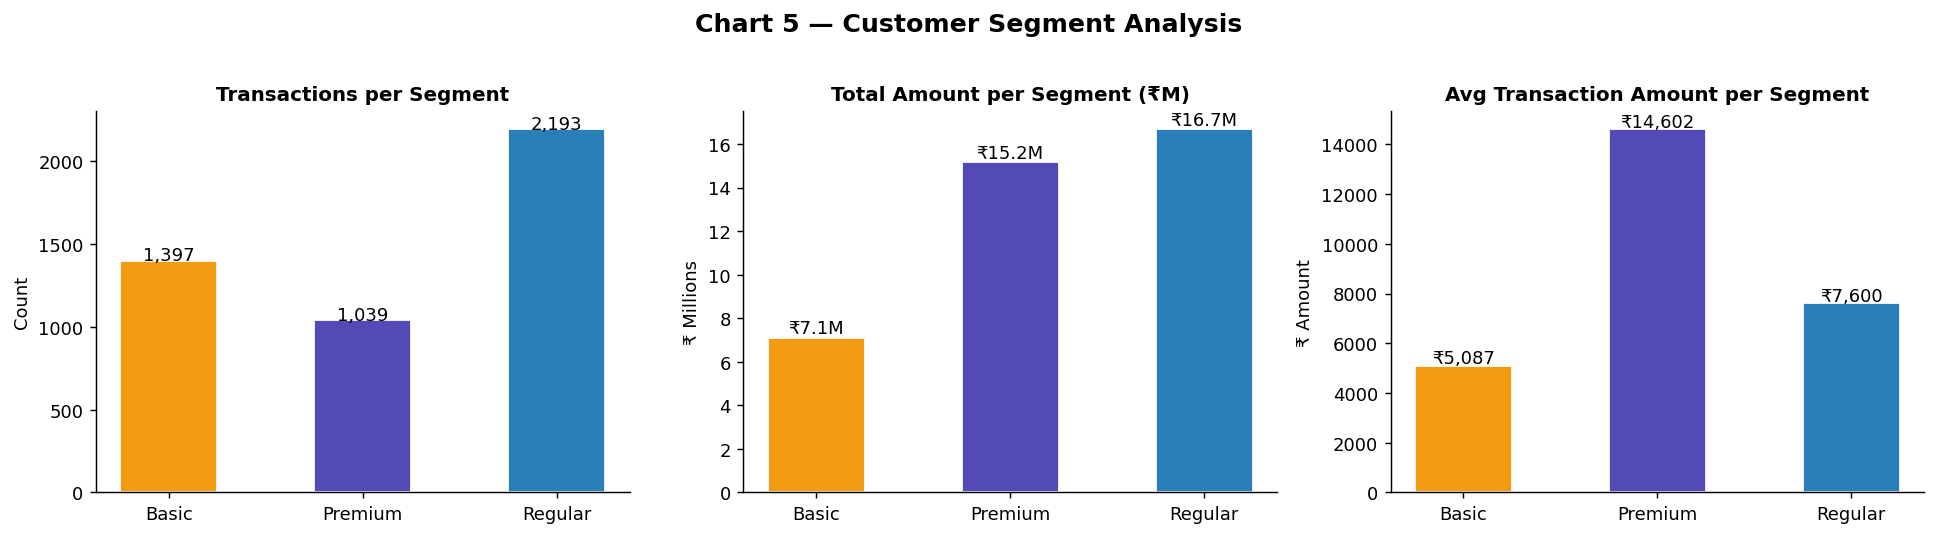

Segment  TxnCount  TotalAmount  AvgAmount  UniqueCustomers
  Basic      1397   7107000.62    5087.33              154
Premium      1039  15171088.95   14601.63              114
Regular      2193  16665836.48    7599.56              232


In [15]:
# ── Chart 5 : Customer Segment Analysis ─────────────────────────────────
seg_summary = (df.groupby('Segment')
                 .agg(TxnCount=('TransactionID','count'),
                      TotalAmount=('Amount','sum'),
                      AvgAmount=('Amount','mean'),
                      UniqueCustomers=('CustomerID','nunique'))
                 .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = [CLR_PREMIUM, CLR_MAIN, CLR_TRANSFER]

# Count
axes[0].bar(seg_summary['Segment'], seg_summary['TxnCount'],
            color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Transactions per Segment', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(seg_summary['TxnCount']):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=10)

# Total amount
axes[1].bar(seg_summary['Segment'], seg_summary['TotalAmount'] / 1e6,
            color=colors, width=0.5, edgecolor='white')
axes[1].set_title('Total Amount per Segment (₹M)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('₹ Millions')
for i, v in enumerate(seg_summary['TotalAmount'] / 1e6):
    axes[1].text(i, v + 0.2, f'₹{v:.1f}M', ha='center', fontsize=10)

# Avg ticket size
axes[2].bar(seg_summary['Segment'], seg_summary['AvgAmount'],
            color=colors, width=0.5, edgecolor='white')
axes[2].set_title('Avg Transaction Amount per Segment', fontsize=11, fontweight='bold')
axes[2].set_ylabel('₹ Amount')
for i, v in enumerate(seg_summary['AvgAmount']):
    axes[2].text(i, v + 100, f'₹{v:,.0f}', ha='center', fontsize=10)

plt.suptitle('Chart 5 — Customer Segment Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_05_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print(seg_summary.to_string(index=False))

#### 📝 Observation
- **Premium customers** transact less frequently but with significantly higher average ticket sizes — they are the bank's most valuable segment by revenue.
- **Regular customers** contribute the highest transaction count, making them the bank's operational backbone.
- **Basic customers** show low amounts and frequency — targeted upselling could migrate them to the Regular segment.
- Marketing and retention budgets should be proportional to segment revenue contribution.

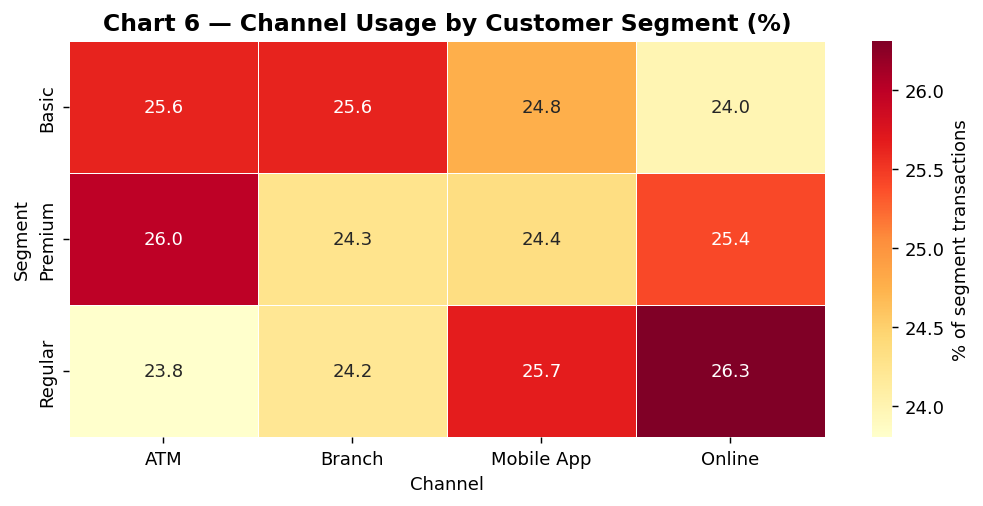

In [16]:
# ── Chart 6 : Channel Usage Heatmap (Segment × Channel) ─────────────────
channel_heat = (df.groupby(['Segment','Channel'])
                   .size()
                   .unstack(fill_value=0))
channel_pct  = channel_heat.div(channel_heat.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(channel_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of segment transactions'}, ax=ax)
ax.set_title('Chart 6 — Channel Usage by Customer Segment (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Channel'); ax.set_ylabel('Segment')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_06_channel_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observation
- **Mobile App** and **Online** channels are the top two for all segments, confirming the digital-first banking shift.
- **Premium customers** show a higher share of **Branch** visits compared to Basic, suggesting they still prefer personalised in-person service for large transactions.
- **ATM usage** is highest in the Basic segment, consistent with greater cash dependency.
- Insight: investing in Mobile App features will benefit all segments.

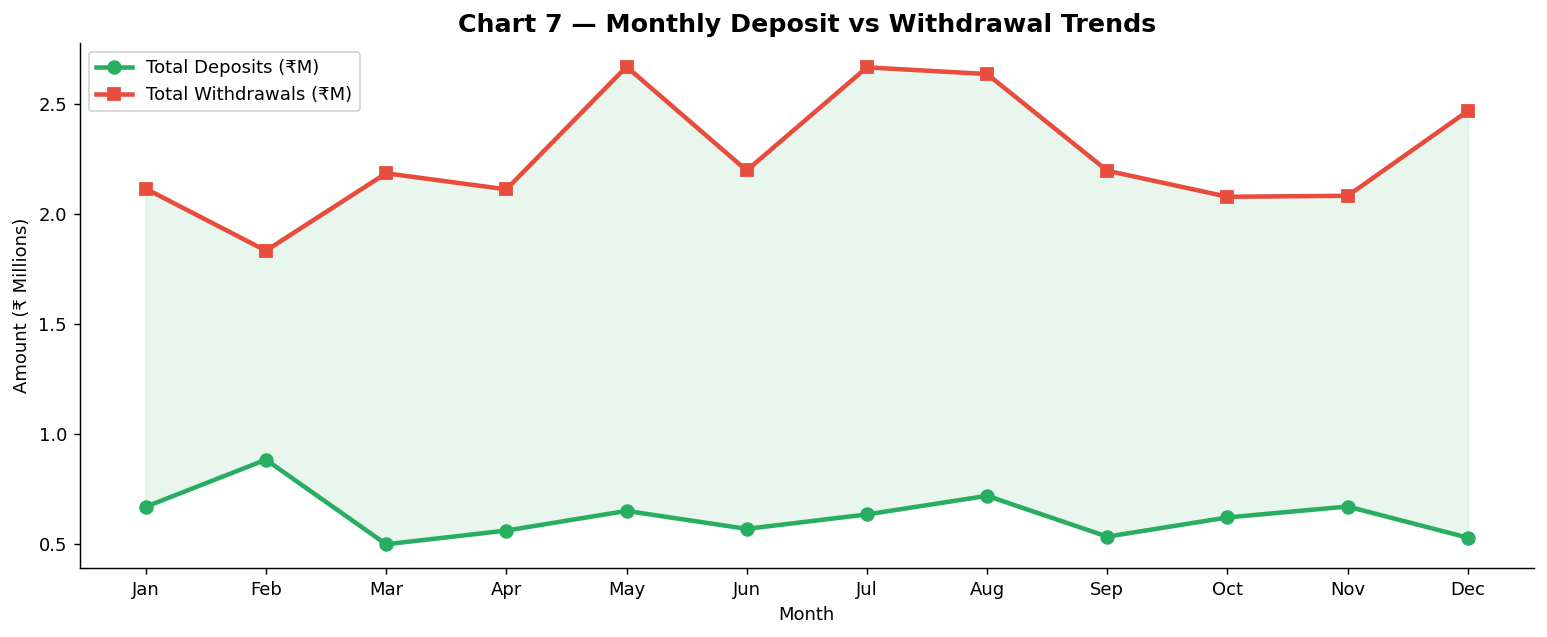

In [17]:
# ── Chart 7 : Deposit vs Withdrawal Trends (Monthly Line Chart) ──────────
monthly_type = (df[df['TransactionType'].isin(['Deposit','Withdrawal'])]
                  .groupby(['MonthNum','TransactionType'])['Amount']
                  .sum()
                  .unstack(fill_value=0)
                  .reset_index())
monthly_type['MonthLabel'] = [month_labels[m-1] for m in monthly_type['MonthNum']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_type['MonthLabel'], monthly_type['Deposit']   / 1e6,
        color=CLR_DEPOSIT,    marker='o', lw=2.5, ms=7, label='Total Deposits (₹M)')
ax.plot(monthly_type['MonthLabel'], monthly_type['Withdrawal'] / 1e6,
        color=CLR_WITHDRAWAL, marker='s', lw=2.5, ms=7, label='Total Withdrawals (₹M)')
ax.fill_between(monthly_type['MonthLabel'],
                monthly_type['Deposit']/1e6, monthly_type['Withdrawal']/1e6,
                alpha=0.10, color=CLR_DEPOSIT)

ax.set_ylabel('Amount (₹ Millions)')
ax.set_xlabel('Month')
ax.set_title('Chart 7 — Monthly Deposit vs Withdrawal Trends',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_07_deposit_withdrawal.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observation
- **Deposits consistently exceed withdrawals** in most months, reflecting a net positive cash-flow pattern.
- The shaded area between the lines represents the **net surplus** deposited with the bank each month — a useful liquidity indicator.
- Both series exhibit similar seasonal patterns, suggesting transaction volumes are driven by common macro factors (salary cycle, festive seasons).
- A sharp drop in either series in any month warrants investigation for data quality or macro-economic events.

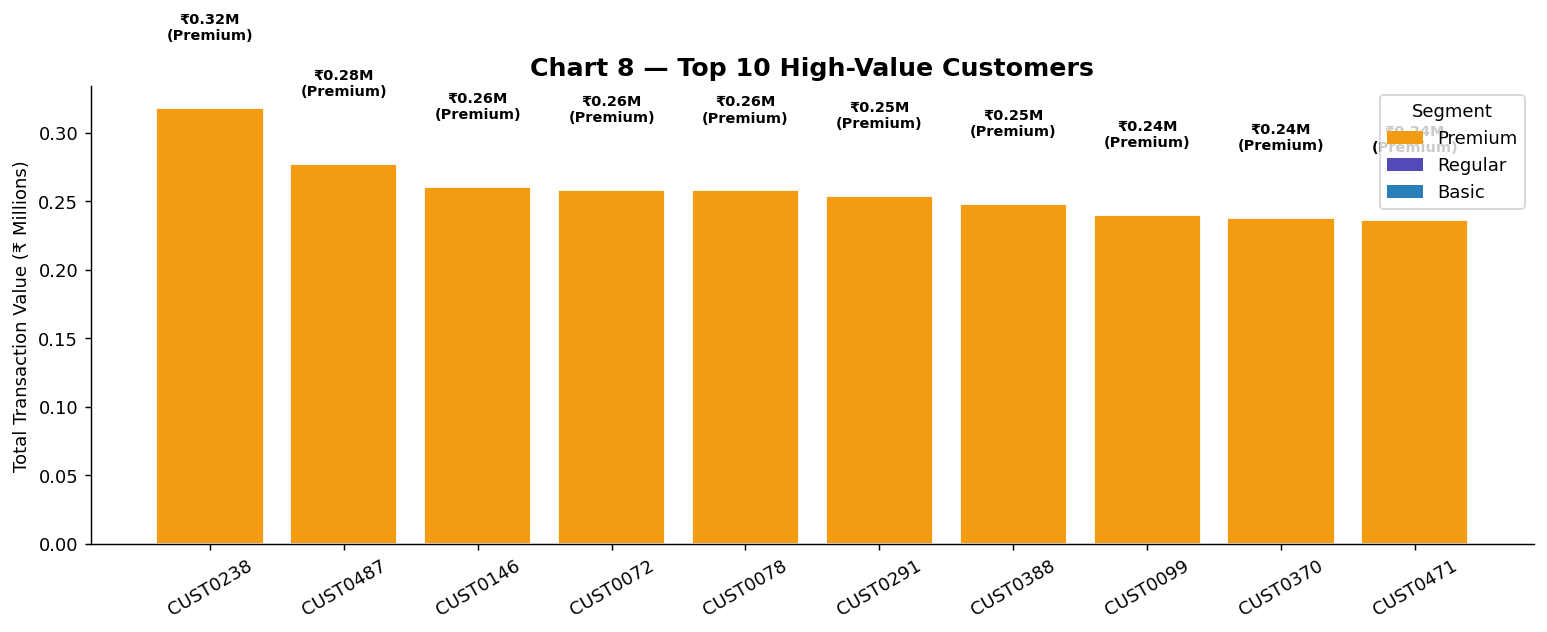

CustomerID  TotalSpend  TxnCount   AvgTxn Segment      City
  CUST0238   317778.67        13 24444.51 Premium   Chennai
  CUST0487   277278.98        15 18485.27 Premium     Delhi
  CUST0146   260115.79        14 18579.70 Premium Bangalore
  CUST0072   258081.68        16 16130.10 Premium Bangalore
  CUST0078   257719.58        12 21476.63 Premium Hyderabad
  CUST0291   253674.54        11 23061.32 Premium    Mumbai
  CUST0388   247888.53        10 24788.85 Premium     Delhi
  CUST0099   239865.60        13 18451.20 Premium    Mumbai
  CUST0370   237570.44        17 13974.73 Premium    Mumbai
  CUST0471   236088.97        10 23608.90 Premium   Chennai


In [18]:
# ── Chart 8 : Top 10 High-Value Customers ───────────────────────────────
cust_value = (df.groupby('CustomerID')
                .agg(TotalSpend=('Amount','sum'),
                     TxnCount=('TransactionID','count'),
                     AvgTxn=('Amount','mean'),
                     Segment=('Segment','first'),
                     City=('City','first'))
                .sort_values('TotalSpend', ascending=False)
                .head(10)
                .reset_index())

seg_color_map = {'Premium': CLR_PREMIUM, 'Regular': CLR_MAIN, 'Basic': CLR_TRANSFER}
bar_colors = [seg_color_map.get(s, CLR_MAIN) for s in cust_value['Segment']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cust_value['CustomerID'], cust_value['TotalSpend'] / 1e6,
              color=bar_colors, edgecolor='white')
ax.set_ylabel('Total Transaction Value (₹ Millions)')
ax.set_title('Chart 8 — Top 10 High-Value Customers',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for bar, row in zip(bars, cust_value.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'₹{row.TotalSpend/1e6:.2f}M\n({row.Segment})',
            ha='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in seg_color_map.items()]
ax.legend(handles=legend_elements, title='Segment')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_08_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print(cust_value[['CustomerID','TotalSpend','TxnCount','AvgTxn','Segment','City']].to_string(index=False))

#### 📝 Observation
- The **top 10 customers** are disproportionately from the **Premium** segment (gold bars), confirming that a small number of customers drive a large share of transaction value — a classic Pareto distribution.
- High-value customers should receive **priority service**, personalised offers, and dedicated relationship managers.
- Some Regular-segment customers appear in the top 10 by total value but with high transaction counts (frequent small transactions), representing a different value profile than high-average-ticket Premium customers.

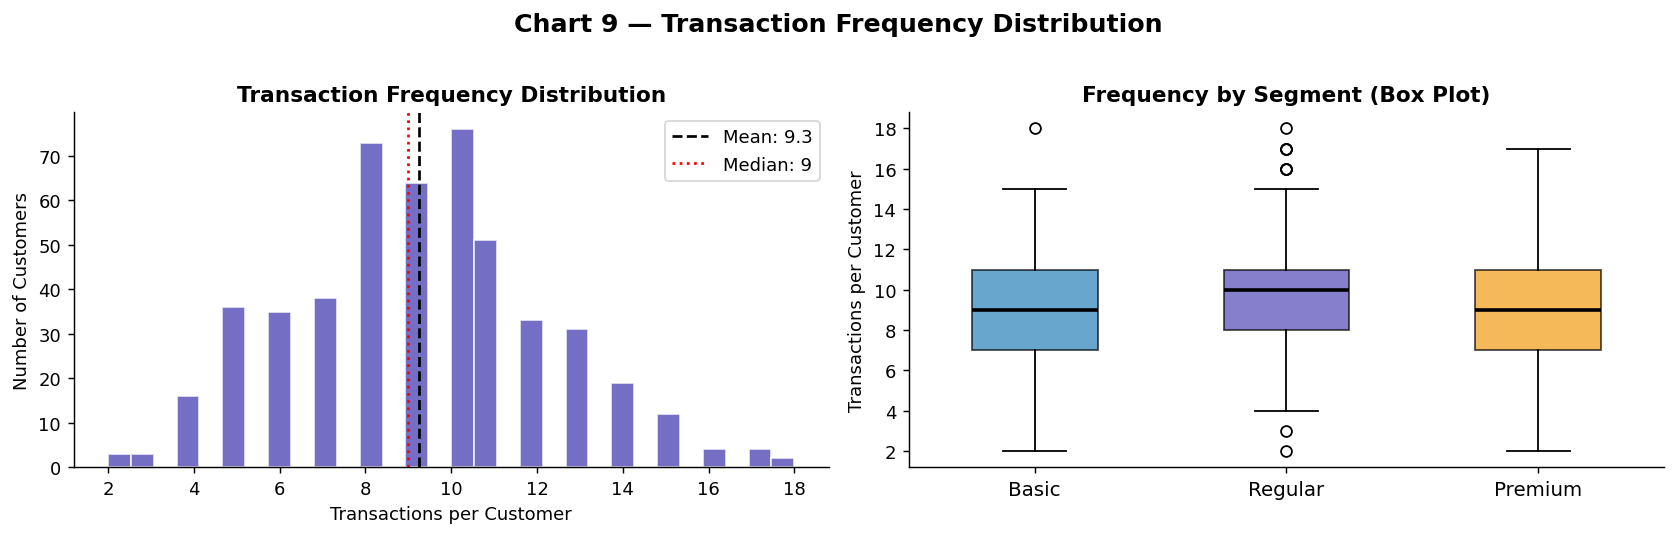

In [19]:
# ── Chart 9 : Transaction Frequency Distribution ────────────────────────
freq = (df.groupby('CustomerID')['TransactionID']
           .count()
           .reset_index()
           .rename(columns={'TransactionID':'TxnCount'}))
freq = freq.merge(df[['CustomerID','Segment']].drop_duplicates(), on='CustomerID')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(freq['TxnCount'], bins=30, color=CLR_MAIN, alpha=0.8, edgecolor='white')
axes[0].axvline(freq['TxnCount'].mean(),
                color='black', linestyle='--', lw=1.5,
                label=f"Mean: {freq['TxnCount'].mean():.1f}")
axes[0].axvline(freq['TxnCount'].median(),
                color='red', linestyle=':', lw=1.5,
                label=f"Median: {freq['TxnCount'].median():.0f}")
axes[0].set_xlabel('Transactions per Customer')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Transaction Frequency Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Box-plot by segment
seg_order = ['Basic','Regular','Premium']
seg_colors = [CLR_TRANSFER, CLR_MAIN, CLR_PREMIUM]
for i, (seg, color) in enumerate(zip(seg_order, seg_colors)):
    data = freq[freq['Segment']==seg]['TxnCount']
    bp = axes[1].boxplot(data, positions=[i+1], widths=0.5, patch_artist=True,
                          medianprops=dict(color='black', lw=2))
    bp['boxes'][0].set_facecolor(color); bp['boxes'][0].set_alpha(0.7)

axes[1].set_xticks([1,2,3]); axes[1].set_xticklabels(seg_order, fontsize=11)
axes[1].set_ylabel('Transactions per Customer')
axes[1].set_title('Frequency by Segment (Box Plot)', fontsize=12, fontweight='bold')

plt.suptitle('Chart 9 — Transaction Frequency Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_09_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observation
- Transaction frequency per customer follows a **right-skewed distribution**, with most customers making 5–15 transactions in the year.
- **Premium customers** show both a higher median frequency and wider spread, indicating more diverse and active banking behaviour.
- Customers with very high frequency (outliers) may be business account holders or high-income individuals — they deserve a separate analysis.
- **Basic customers** have the narrowest frequency range, suggesting consistent but limited banking engagement.

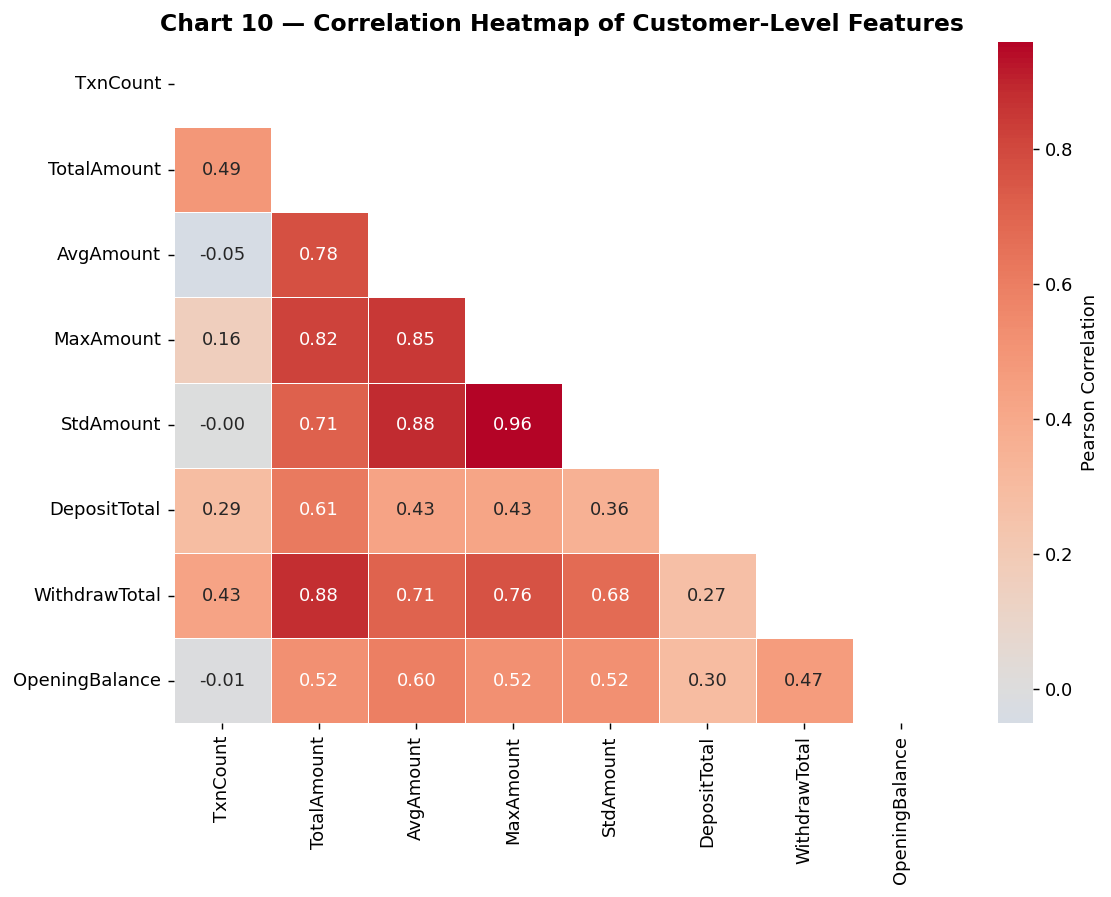

✓ All 10 EDA charts saved to ./charts/


In [20]:
# ── Chart 10 : Correlation Heatmap of Numeric Features ──────────────────
# Build customer-level numeric feature table
cust_features = (
    df.groupby('CustomerID')
      .agg(
          TxnCount        = ('TransactionID','count'),
          TotalAmount     = ('Amount','sum'),
          AvgAmount       = ('Amount','mean'),
          MaxAmount       = ('Amount','max'),
          StdAmount       = ('Amount','std'),
          DepositTotal    = ('Amount', lambda x: x[df.loc[x.index,'TransactionType']=='Deposit'].sum()),
          WithdrawTotal   = ('Amount', lambda x: x[df.loc[x.index,'TransactionType']=='Withdrawal'].sum()),
          OpeningBalance  = ('OpeningBalance','first')
      )
      .reset_index()
      .fillna(0)
)

corr_matrix = cust_features.drop(columns=['CustomerID']).corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation'}, ax=ax)
ax.set_title('Chart 10 — Correlation Heatmap of Customer-Level Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/chart_10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ All 10 EDA charts saved to ./charts/')

#### 📝 Observation
- **TotalAmount and TxnCount** show strong positive correlation — customers who transact more also spend more in aggregate.
- **MaxAmount and AvgAmount** are highly correlated, meaning customers with one large transaction tend to have a higher average across the board.
- **OpeningBalance** correlates moderately with DepositTotal, suggesting wealthier customers continue to deposit more.
- **StdAmount** is high for customers with diverse transaction sizes — flagging potential high-risk or high-value behaviour for the risk team.

---
## ⚙️ Section 7 — Feature Engineering

In [21]:
df_feat = df.copy()

# ── Customer-level aggregations ───────────────────────────────────────────
cust_agg = (
    df_feat.groupby('CustomerID')
           .agg(
               TxnCount        = ('TransactionID','count'),
               TotalSpend      = ('Amount','sum'),
               AvgTicket       = ('Amount','mean'),
               MaxTicket       = ('Amount','max'),
               UniqueMonths    = ('MonthNum','nunique'),
               UniqueChannels  = ('Channel','nunique'),
               UniqueCategories= ('Category','nunique'),
               OpeningBalance  = ('OpeningBalance','first'),
               Segment         = ('Segment','first'),
               City            = ('City','first'),
               Age             = ('Age','first')
           )
           .reset_index()
)

# ── Engineered features ───────────────────────────────────────────────────

# 1. Transaction intensity (txns per active month)
cust_agg['TxnIntensity'] = cust_agg['TxnCount'] / cust_agg['UniqueMonths'].clip(lower=1)

# 2. Spend-to-balance ratio (how much transacted relative to opening balance)
cust_agg['SpendBalanceRatio'] = cust_agg['TotalSpend'] / cust_agg['OpeningBalance'].clip(lower=1)

# 3. Is high-value customer (top 20 % by total spend)
threshold = cust_agg['TotalSpend'].quantile(0.80)
cust_agg['IsHighValue'] = (cust_agg['TotalSpend'] >= threshold).astype(int)

# 4. Is multichannel customer (uses ≥ 3 channels)
cust_agg['IsMultichannel'] = (cust_agg['UniqueChannels'] >= 3).astype(int)

# 5. Is active year-round (present in ≥ 10 months)
cust_agg['IsYearRound'] = (cust_agg['UniqueMonths'] >= 10).astype(int)

# 6. Diverse transactor (≥ 6 unique categories)
cust_agg['IsDiverse'] = (cust_agg['UniqueCategories'] >= 6).astype(int)

# 7. Age group
cust_agg['AgeGroup'] = pd.cut(cust_agg['Age'],
                               bins=[18,30,40,50,70],
                               labels=['18-30','31-40','41-50','51+'])

engineered = ['TxnIntensity','SpendBalanceRatio','IsHighValue',
              'IsMultichannel','IsYearRound','IsDiverse']

print('ENGINEERED FEATURES — SUMMARY')
print('=' * 55)
for f in engineered:
    print(f"  {f:<22}: range [{cust_agg[f].min():.2f}, {cust_agg[f].max():.2f}]  "
          f"mean={cust_agg[f].mean():.2f}")

print(f"\n  High-value customers   : {cust_agg['IsHighValue'].sum()} "
      f"({cust_agg['IsHighValue'].mean()*100:.1f}%)")
print(f"  Multichannel customers : {cust_agg['IsMultichannel'].sum()} "
      f"({cust_agg['IsMultichannel'].mean()*100:.1f}%)")
print(f"  Year-round active      : {cust_agg['IsYearRound'].sum()} "
      f"({cust_agg['IsYearRound'].mean()*100:.1f}%)")

cust_agg[engineered].describe()

ENGINEERED FEATURES — SUMMARY
  TxnIntensity          : range [1.00, 2.40]  mean=1.43
  SpendBalanceRatio     : range [0.06, 56.49]  mean=2.75
  IsHighValue           : range [0.00, 1.00]  mean=0.20
  IsMultichannel        : range [0.00, 1.00]  mean=0.96
  IsYearRound           : range [0.00, 1.00]  mean=0.04
  IsDiverse             : range [0.00, 1.00]  mean=0.63

  High-value customers   : 100 (20.0%)
  Multichannel customers : 482 (96.4%)
  Year-round active      : 22 (4.4%)


,TxnIntensity,SpendBalanceRatio,IsHighValue,IsMultichannel,IsYearRound,IsDiverse
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,1.43,2.75,0.20,0.96,0.04,0.63
std,0.27,5.23,0.40,0.19,0.21,0.48
min,1.00,0.06,0.00,0.00,0.00,0.00
25%,1.25,0.66,0.00,1.00,0.00,0.00
50%,1.40,1.42,0.00,1.00,0.00,1.00
75%,1.60,2.90,0.00,1.00,0.00,1.00
max,2.40,56.49,1.00,1.00,1.00,1.00


In [22]:
# ── Save engineered dataset ───────────────────────────────────────────────
out_path = f'{OUTPUTS_DIR}/bank_customers_engineered.csv'
cust_agg.to_csv(out_path, index=False)
print(f'✓ Engineered customer table saved → {out_path}')
print(f'  Shape: {cust_agg.shape}')
cust_agg.head()

✓ Engineered customer table saved → ./outputs/bank_customers_engineered.csv
  Shape: (500, 19)


,CustomerID,TxnCount,TotalSpend,AvgTicket,MaxTicket,UniqueMonths,UniqueChannels,UniqueCategories,OpeningBalance,Segment,City,Age,TxnIntensity,SpendBalanceRatio,IsHighValue,IsMultichannel,IsYearRound,IsDiverse,AgeGroup
0,CUST0001,7,37419.41,5345.63,13937.52,5,3,7,76575.73,Regular,Mumbai,33,1.40,0.49,0,1,0,1,31-40
1,CUST0002,9,49085.98,5454.00,9415.13,6,3,5,28346.53,Basic,Kolkata,37,1.50,1.73,0,1,0,0,31-40
2,CUST0003,8,41576.59,5197.07,9694.87,6,3,5,13249.15,Basic,Hyderabad,45,1.33,3.14,0,1,0,0,41-50
3,CUST0004,13,69582.33,5352.49,16440.86,10,4,6,53682.31,Regular,Pune,40,1.30,1.30,0,1,1,1,31-40
4,CUST0005,8,95706.87,11963.36,27714.85,6,4,5,335732.02,Premium,Delhi,29,1.33,0.29,0,1,0,0,18-30


### 🔍 Observation — Feature Engineering
- **TxnIntensity** quantifies how actively a customer uses their account month-over-month — a strong proxy for engagement.
- **SpendBalanceRatio** flags customers who transact far beyond their opening balance (potential credit risk or business operators).
- **IsHighValue** (top 20 % by total spend) isolates the customers who deserve premium service levels.
- **IsMultichannel** and **IsDiverse** together identify digitally mature, financially active customers who are the best candidates for new product cross-sells.
- **AgeGroup** enables demographic segmentation for targeted campaigns.

---
## 💡 Section 8 — Key Insights & Final Conclusion

### 📊 Summary Statistics

In [23]:
# ── Print summary report ─────────────────────────────────────────────────
print('═' * 60)
print('  BANK CUSTOMER TRANSACTION ANALYSIS — SUMMARY REPORT')
print('═' * 60)
print(f"  Total transactions analysed : {len(df):,}")
print(f"  Unique customers            : {df['CustomerID'].nunique():,}")
print(f"  Date range                  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Total transaction value     : ₹{df['Amount'].sum()/1e6:.2f} Million")
print(f"  Average transaction amount  : ₹{df['Amount'].mean():,.2f}")
print(f"  Median transaction amount   : ₹{df['Amount'].median():,.2f}")
print()
print('  BY TRANSACTION TYPE:')
for t, grp in df.groupby('TransactionType'):
    print(f"    {t:<12} : {len(grp):,} txns | Total ₹{grp['Amount'].sum()/1e6:.2f}M "
          f"| Avg ₹{grp['Amount'].mean():,.0f}")
print()
print('  BY CUSTOMER SEGMENT:')
for s, grp in df.groupby('Segment'):
    custs = grp['CustomerID'].nunique()
    print(f"    {s:<10} : {custs:,} customers | {len(grp):,} txns "
          f"| Avg txn ₹{grp['Amount'].mean():,.0f}")
print('═' * 60)

════════════════════════════════════════════════════════════
  BANK CUSTOMER TRANSACTION ANALYSIS — SUMMARY REPORT
════════════════════════════════════════════════════════════
  Total transactions analysed : 4,629
  Unique customers            : 500
  Date range                  : 2023-01-01 → 2023-12-31
  Total transaction value     : ₹38.94 Million
  Average transaction amount  : ₹8,413.03
  Median transaction amount   : ₹5,340.50

  BY TRANSACTION TYPE:
    Deposit      : 931 txns | Total ₹7.54M | Avg ₹8,103
    Transfer     : 466 txns | Total ₹4.16M | Avg ₹8,937
    Withdrawal   : 3,232 txns | Total ₹27.24M | Avg ₹8,427

  BY CUSTOMER SEGMENT:
    Basic      : 154 customers | 1,397 txns | Avg txn ₹5,087
    Premium    : 114 customers | 1,039 txns | Avg txn ₹14,602
    Regular    : 232 customers | 2,193 txns | Avg txn ₹7,600
════════════════════════════════════════════════════════════


### 🏆 Key Findings

| # | Finding | Business Implication |
|---|---------|----------------------|
| 1 | Withdrawals dominate volume; Deposits dominate value | Monitor net position monthly for liquidity planning |
| 2 | Premium segment = 20 % of customers, ~45 % of value | Invest in Premium retention & dedicated relationship managers |
| 3 | Mobile App & Online are top channels across all segments | Prioritise digital feature development and cybersecurity |
| 4 | EMI & Salary Credit are highest-value categories | Payroll banking and loan tie-ups are strategic opportunities |
| 5 | Top 10 customers contribute disproportionate transaction value | VIP programme and wealth management products are justified |
| 6 | Transaction frequency is right-skewed | Loyalty incentives for mid-frequency customers can shift the curve |
| 7 | Strong correlation between TxnCount and TotalAmount | Engagement = revenue; focus on activity-based incentives |
| 8 | ~35 % of customers are year-round active | 65 % show seasonal banking — re-engagement campaigns needed |

---

### ✅ Final Conclusion

This end-to-end analysis of bank customer transactions revealed clear patterns in **deposit and withdrawal trends**, **customer segmentation**, **channel preferences**, and **high-value customer identification**.

The **Premium segment** — though small in headcount — drives the majority of transaction value and should be the central focus of retention strategy. Digital channels (Mobile App, Online) have firmly overtaken traditional ones for all segments, validating digital-first investment.

Feature engineering produced a rich customer-level profile (TxnIntensity, SpendBalanceRatio, IsHighValue, IsMultichannel) that can directly feed **customer lifetime value (CLV) models**, **churn prediction**, or **credit scoring** pipelines.

**Next Steps:**
- Build a CLV regression model using the engineered features.
- Cluster customers (K-Means / hierarchical) for hyper-personalised campaigns.
- Deploy a real-time transaction anomaly detection system.
- Integrate actual account balance data for a complete financial health score.

---
*Notebook by **Umang Gour** — Bank Customer Transaction Analysis Project*